In [8]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

### 1

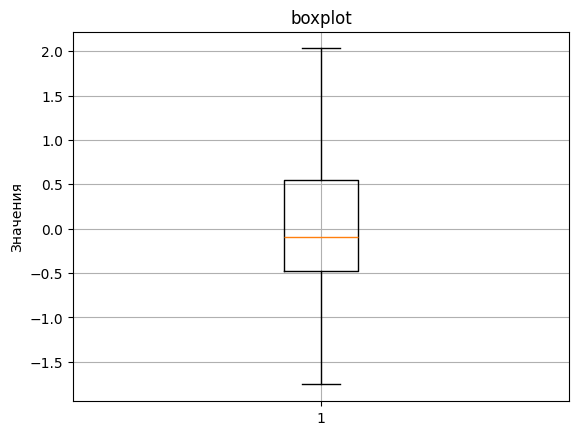

In [12]:
# Равномерное распределение и ящик с усами
data = norm.rvs(loc=0, scale=1, size=100)
plt.boxplot(data)
plt.title("boxplot")
plt.ylabel("Значения")
plt.grid(True)
plt.show()

In [2]:
# Данные
data = [79, 80, 80, 80, 74, 80, 80, 79, 64, 78, 73, 78, 74, 45, 81, 48, 80, 82, 82, 70]

# (a) Вычисление квартилей
Q1 = np.percentile(data, 25)
Q2 = np.median(data)  # Медиана (Q2)
Q3 = np.percentile(data, 75)
print(f"(a) Квартили: Q1 = {Q1}, Q2 (медиана) = {Q2}, Q3 = {Q3}")

(a) Квартили: Q1 = 73.75, Q2 (медиана) = 79.0, Q3 = 80.0


In [3]:
# (b) Межквартильный размах (IQR)
IQR = Q3 - Q1
print(f"(b) Межквартильный размах (IQR): {IQR}")

(b) Межквартильный размах (IQR): 6.25


In [4]:
# (c) Минимум, Q25, медиана, Q75, максимум
minimum = np.min(data)
maximum = np.max(data)
print(f"(c) Минимум: {minimum}, Q25: {Q1}, Медиана: {Q2}, Q75: {Q3}, Максимум: {maximum}")

(c) Минимум: 45, Q25: 73.75, Медиана: 79.0, Q75: 80.0, Максимум: 82


In [5]:
# (d) Определение потенциальных выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = [x for x in data if x < lower_bound or x > upper_bound]
print(f"(d) Потенциальные выбросы: {outliers}")

(d) Потенциальные выбросы: [64, 45, 48]


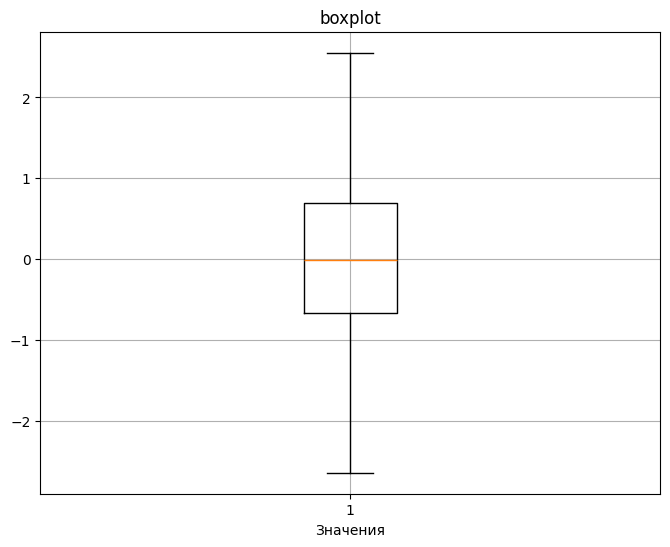

In [10]:
# (e) Построение ящика с усами
plt.figure(figsize=(8, 6))
plt.boxplot(data)
plt.title('boxplot')
plt.xlabel('Значения')
plt.grid(True)

### 2

```
#!/bin/bash
#SBATCH --job-name=fastqc_multiqc
#SBATCH --output=fastqc_multiqc.out
#BATCH --error=fastqc_multiqc.err
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=4
#SBATCH --time=02:00:00
#SBATCH --mem=8G

# making folders
mkdir -p raw_data fastqc_results

cd raw_data

curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/007/ERR14230607/ERR14230607.fastq.gz -o ERR14230607_Illumina_HiSeq_4000_sequencing.fastq.gz
curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/086/ERR14230586/ERR14230586.fastq.gz -o ERR14230586_Illumina_HiSeq_4000_sequencing.fastq.gz
curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/095/ERR14230595/ERR14230595.fastq.gz -o ERR14230595_Illumina_HiSeq_4000_sequencing.fastq.gz
curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/000/ERR14230600/ERR14230600.fastq.gz -o ERR14230600_Illumina_HiSeq_4000_sequencing.fastq.gz


cd ..

# fastqc
fastqc raw_data/*.fastq.gz -o fastqc_results -t 4

# multiqc
multiqc fastqc_results -o fastqc_results
```